In [69]:
import joblib 
import os 
import sys 
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)


In [ ]:
generated_data = joblib.load(parent_dir + f'/results/GAN_only/Oct2_all_seed_generated_data.pkl')
simulated_v_pf_data = joblib.load(parent_dir + f'/results/GAN_only/Oct2_all_seed_simulated_v_pf_data.pkl')
all_losses_seeds = joblib.load(parent_dir + f'/results/GAN_only/Oct2_all_seed_losses_data.pkl')

seeds = np.arange(len(generated_data.keys()))

generated_v_df = pd.DataFrame(columns=seeds)
simulated_v_pf_data_df = pd.DataFrame(columns=seeds)
all_val_g_losses_df = pd.DataFrame(columns=seeds)
all_val_d_losses_df = pd.DataFrame(columns=seeds)
all_val_d_accuracies_df = pd.DataFrame(columns=seeds)

num_buses = 42

for seed in seeds: 
    all_val_g_losses_df[seed] = all_losses_seeds[seed]['val_g_losses']
    all_val_d_losses_df[seed] = all_losses_seeds[seed]['val_d_losses']
    all_val_d_accuracies_df[seed] = all_losses_seeds[seed]['val_d_accuracies']
    try: 
        generated_v_df[seed] = generated_data[seed]['gen_v'][:num_buses]
        simulated_v_pf_data_df[seed] = simulated_v_pf_data[seed]
    except Exception as e: 
        print(e)
generated_v_df.dropna(axis='columns', inplace=True)
simulated_v_pf_data_df.dropna(axis='columns', inplace=True)

'int' object is not subscriptable


In [71]:
val_d_losses_mean = all_val_d_losses_df.mean(axis=1)
val_d_losses_std = all_val_d_losses_df.std(axis=1)

val_g_losses_mean = all_val_g_losses_df.mean(axis=1)
val_g_losses_std = all_val_g_losses_df.std(axis=1)

val_d_accuracies_mean = all_val_d_accuracies_df.mean(axis=1)
val_d_accuracies_std = all_val_d_accuracies_df.std(axis=1)

x = range(len(val_d_losses_mean))

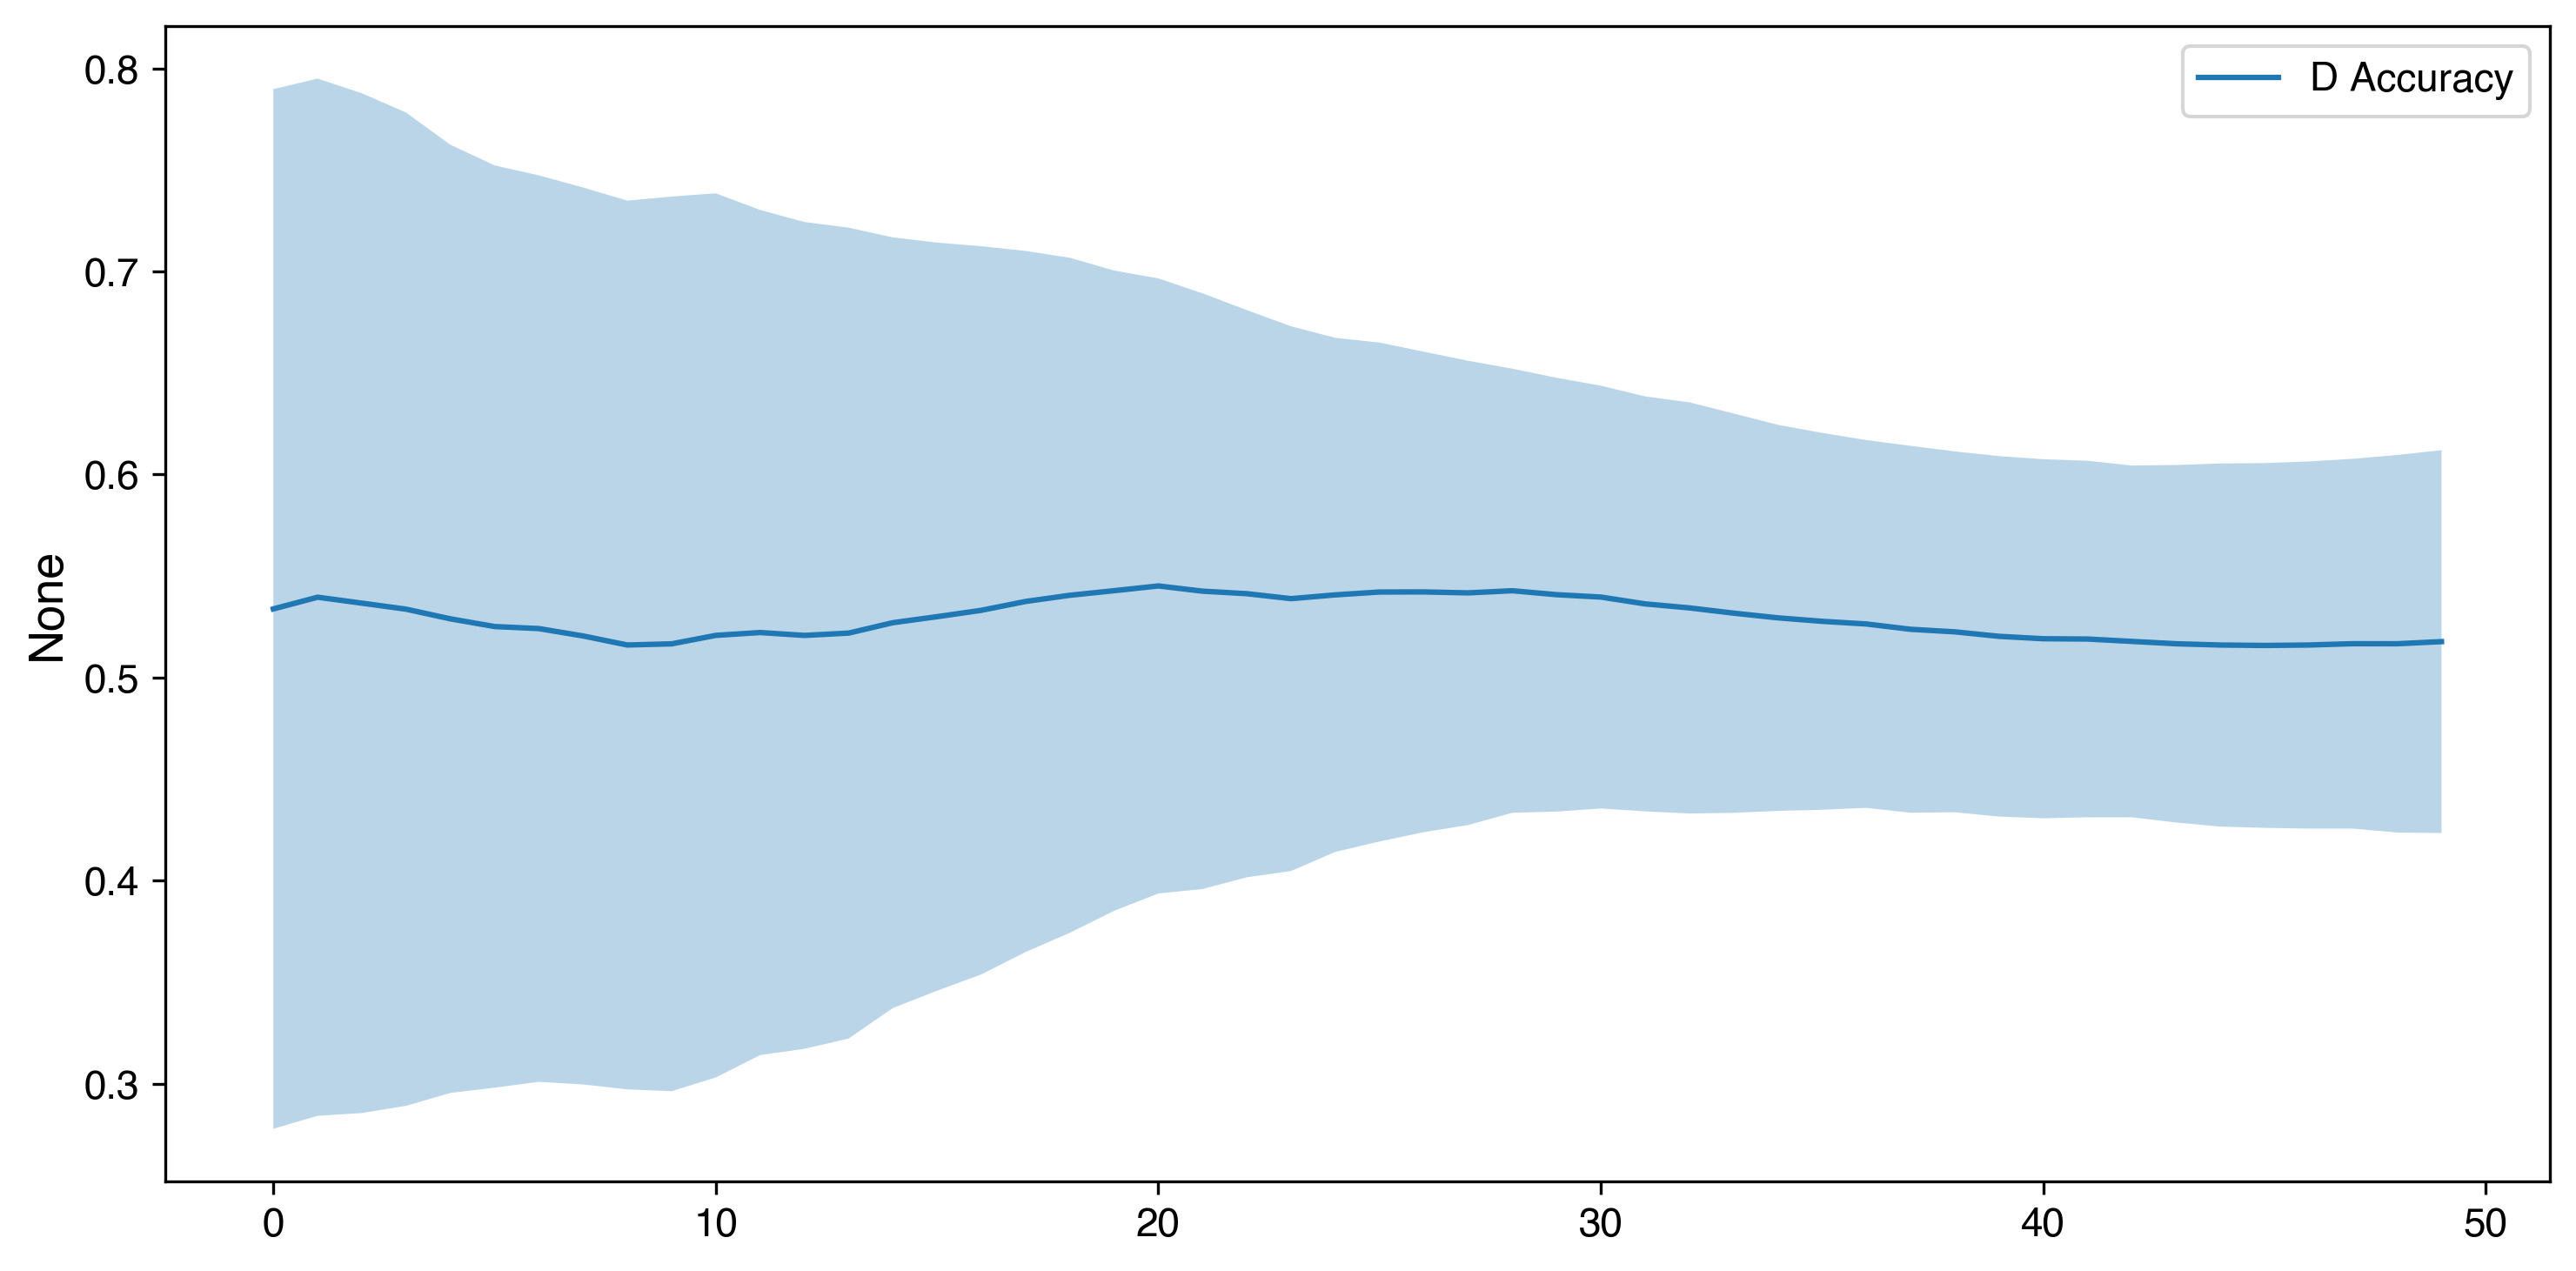

In [72]:
fig, ax = plt.subplots(figsize=(10,5))
sns.lineplot(x=x, y=val_d_accuracies_mean, label='D Accuracy')
ax.fill_between(x, val_d_accuracies_mean - val_d_accuracies_std, val_d_accuracies_mean + val_d_accuracies_std, alpha=0.3)
plt.tight_layout()


### Figure: Discriminator accuracy vs. epochs 

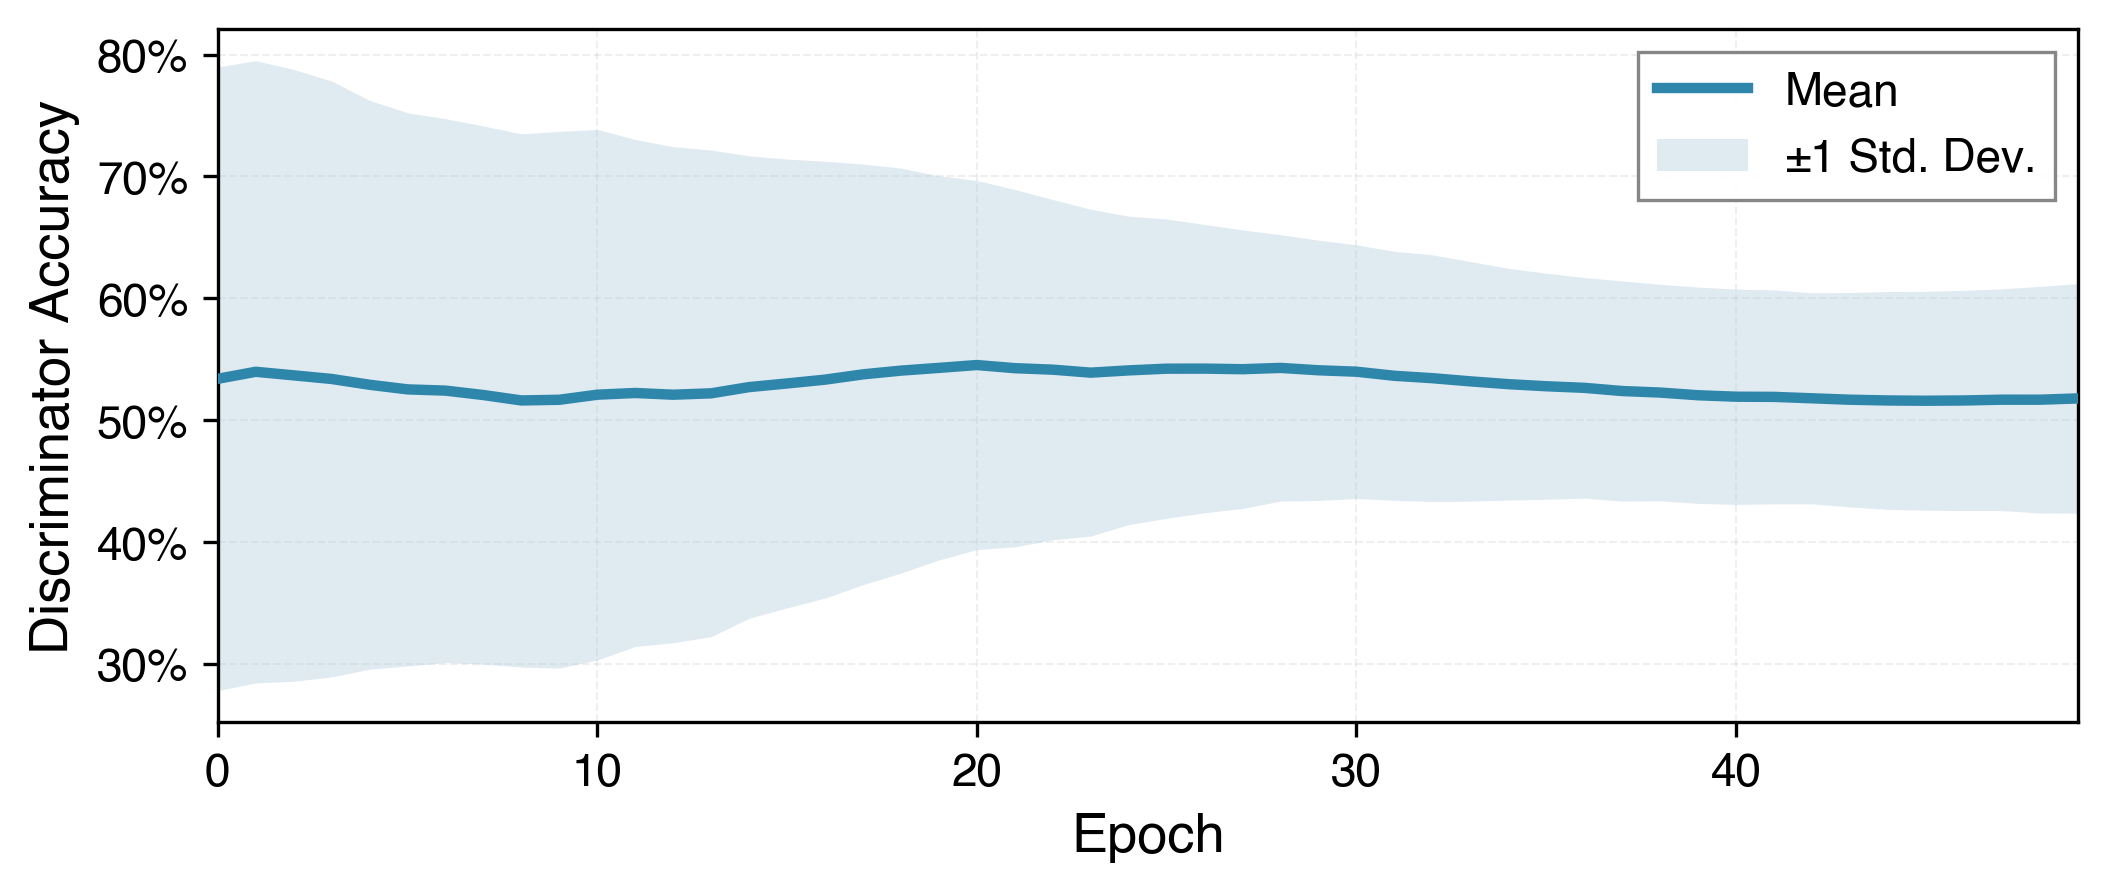

In [73]:
# Set publication-quality style with modern academic fonts
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'  # Modern math font
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'semibold'

# Create figure with better proportions
fig, ax = plt.subplots(figsize=(8, 3))

# Use a sophisticated color palette
color = '#2E86AB'  # Professional blue
fill_color = '#A7C5D9'  # Lighter blue for confidence interval

# Plot with refined styling
line = ax.plot(x, val_d_accuracies_mean, 
               color=color, 
               linewidth=2.5, 
               label='Mean',
               zorder=3)

# Confidence interval with subtle transparency
ax.fill_between(x, 
                val_d_accuracies_mean - val_d_accuracies_std, 
                val_d_accuracies_mean + val_d_accuracies_std, 
                color=fill_color,
                alpha=0.35,
                linewidth=0,
                label='±1 Std. Dev.',
                zorder=2)

# Styling improvements
ax.set_xlabel('Epoch', fontweight='normal')
ax.set_ylabel('Discriminator Accuracy', fontweight='normal')
# ax.set_title('Discriminator Performance During Training', 
#              fontweight='normal', pad=15)

# Add grid for readability (subtle)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=1)
ax.set_axisbelow(True)
ax.set_xlim(0,49)

# Set y-axis to percentage if needed (0-1 range)
if val_d_accuracies_mean.max() <= 1.0:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Clean up spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible()
# ax.spines['left'].set_linewidth(0.8)
# ax.spines['bottom'].set_linewidth(0.8)

# Legend with refined styling
legend = ax.legend(frameon=True, 
                   loc='best',
                   framealpha=0.95,
                   edgecolor='gray',
                   fancybox=False,
                   shadow=False)
legend.get_frame().set_linewidth(0.8)

# Tight layout with padding
# plt.tight_layout(pad=0.0)

# Save as high-quality PDF and PNG
plt.savefig('FIG_discriminator_accuracy.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('discriminator_accuracy.png', dpi=300, bbox_inches='tight')

plt.show()

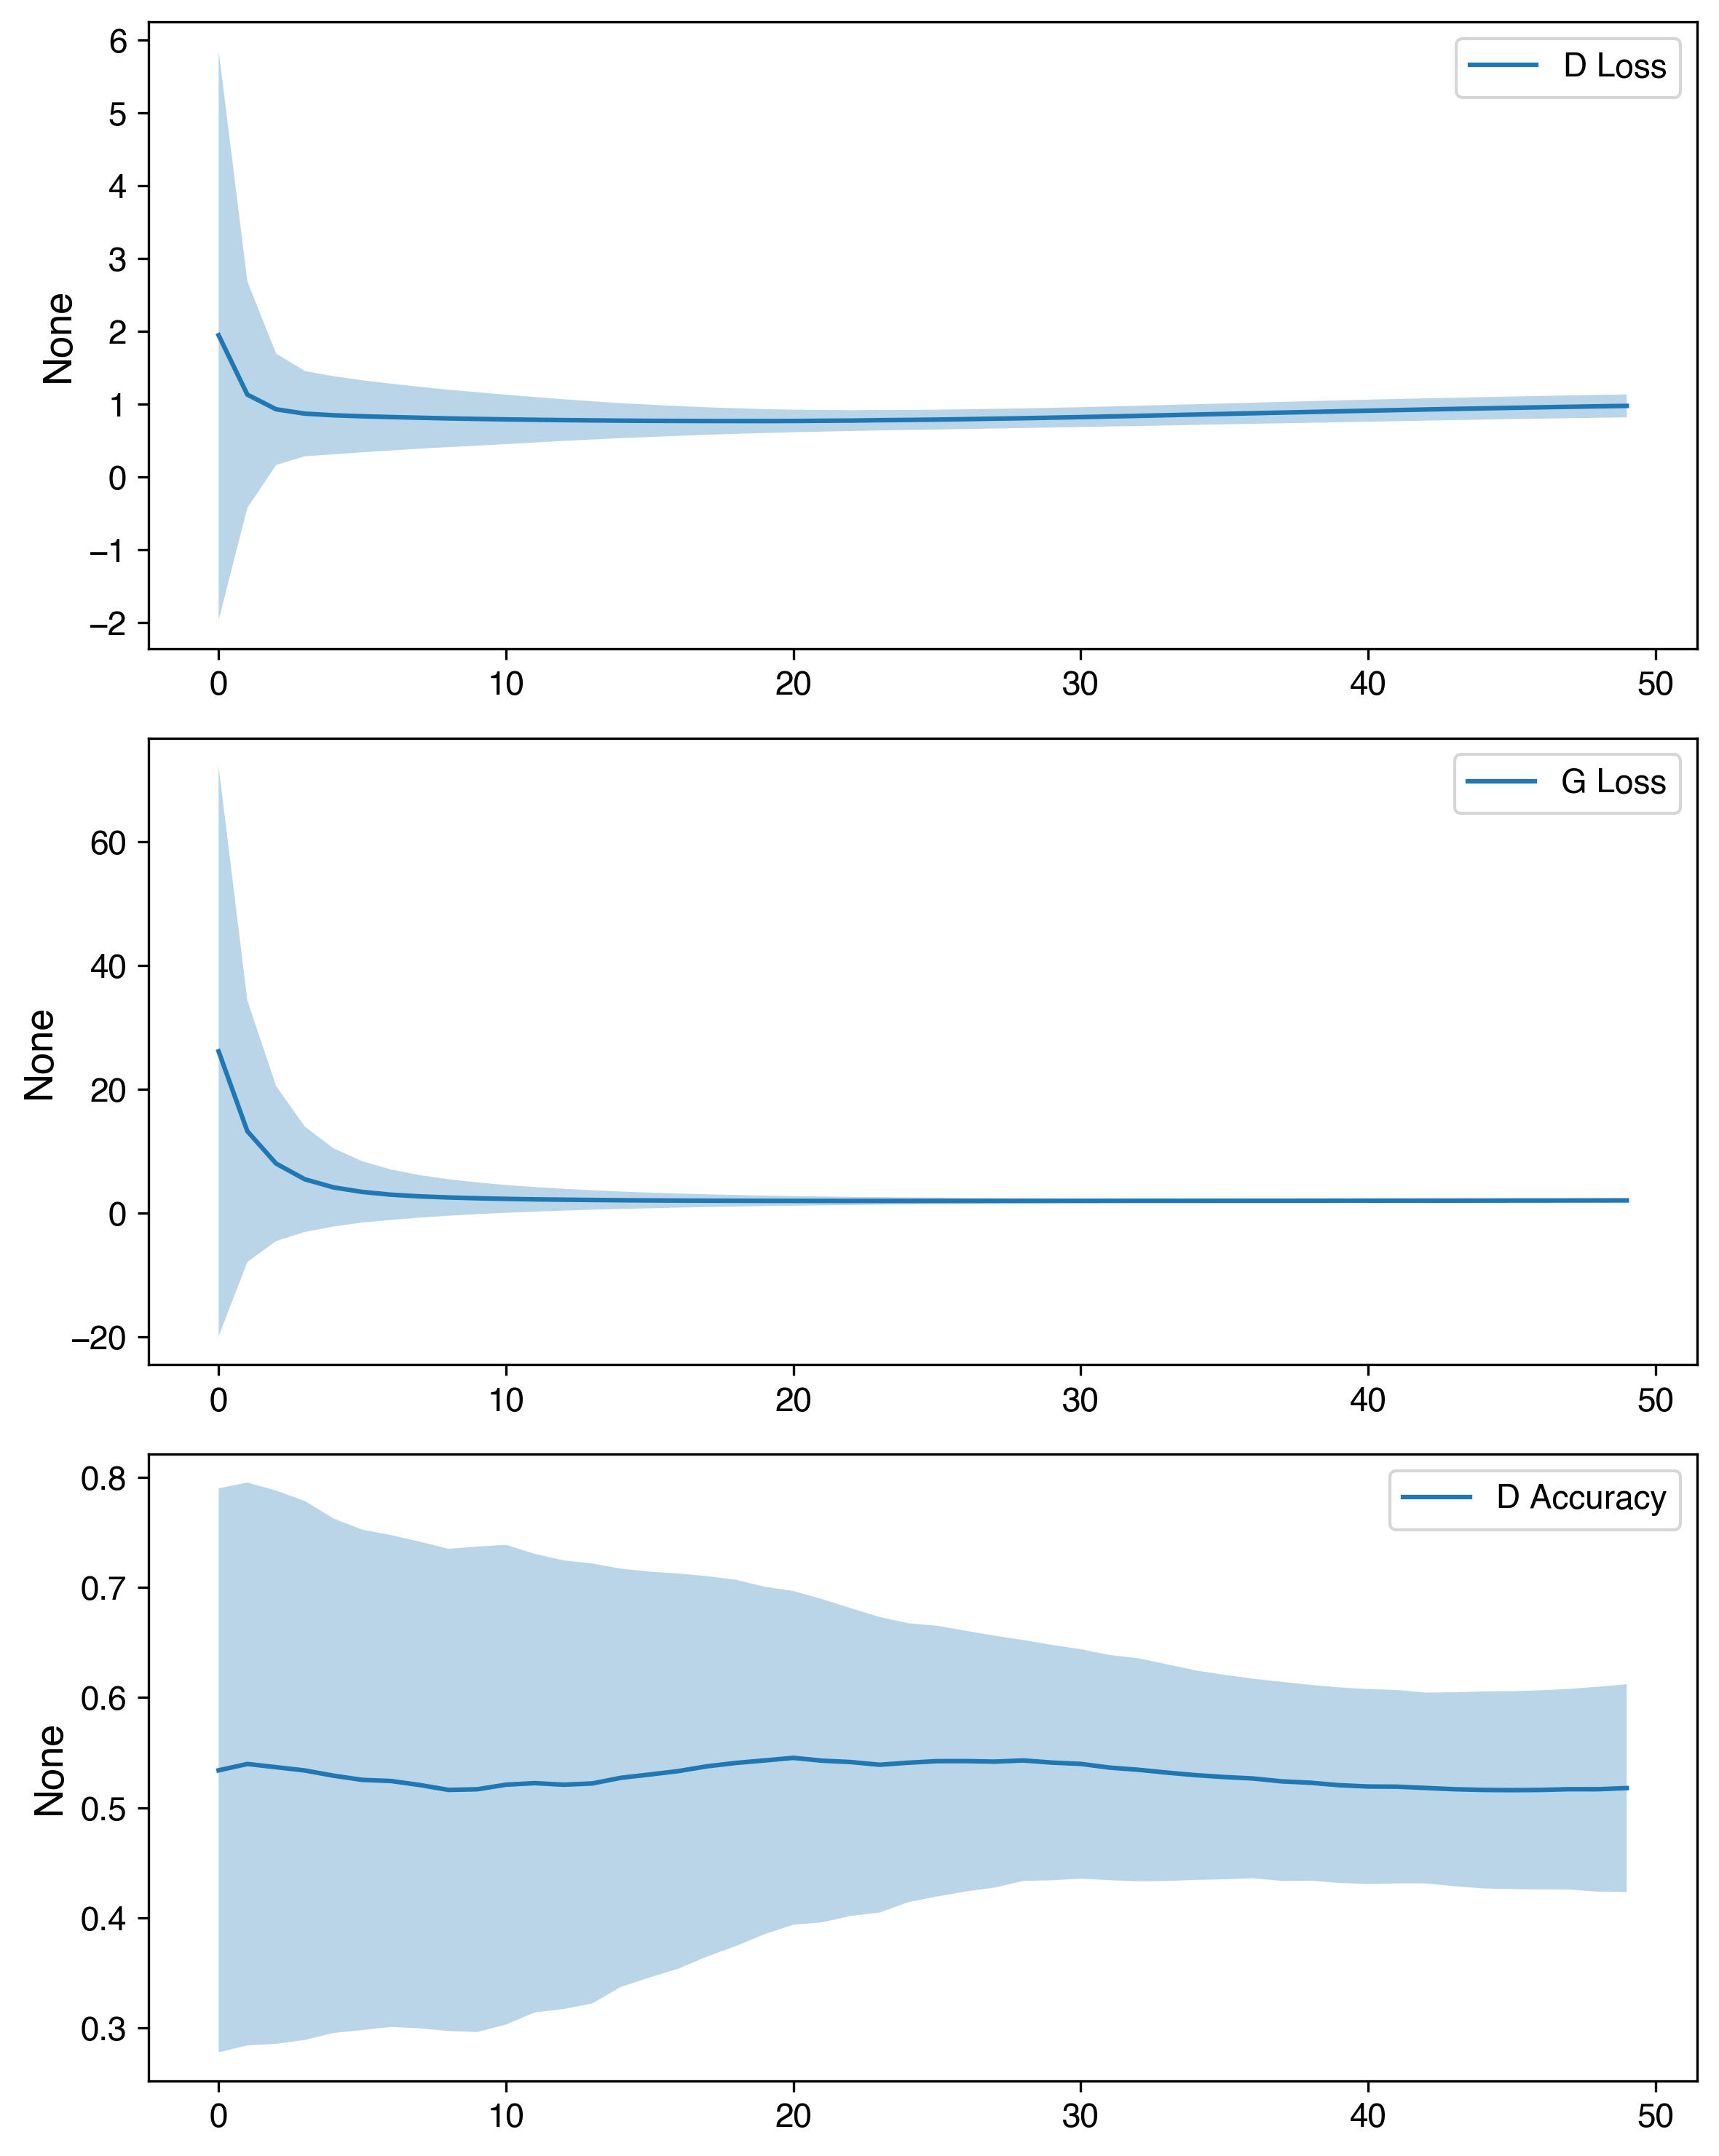

In [14]:
val_d_losses_mean = all_val_d_losses_df.mean(axis=1)
val_d_losses_std = all_val_d_losses_df.std(axis=1)

val_g_losses_mean = all_val_g_losses_df.mean(axis=1)
val_g_losses_std = all_val_g_losses_df.std(axis=1)

val_d_accuracies_mean = all_val_d_accuracies_df.mean(axis=1)
val_d_accuracies_std = all_val_d_accuracies_df.std(axis=1)

fig, ax = plt.subplots(3,1, figsize=(8,10))
x = range(len(val_d_losses_mean))

sns.lineplot(x=x, y=val_d_losses_mean, ax=ax[0], label='D Loss')
ax[0].fill_between(x, val_d_losses_mean - val_d_losses_std, val_d_losses_mean + val_d_losses_std, alpha=0.3)

sns.lineplot(x=x, y=val_g_losses_mean, ax=ax[1], label='G Loss')
ax[1].fill_between(x, val_g_losses_mean - val_g_losses_std, val_g_losses_mean + val_g_losses_std, alpha=0.3)

sns.lineplot(x=x, y=val_d_accuracies_mean, ax=ax[2], label='D Accuracy')
ax[2].fill_between(x, val_d_accuracies_mean - val_d_accuracies_std, val_d_accuracies_mean + val_d_accuracies_std, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Calculate mean and standard deviation for both dataframes
# simulated_mean = simulated_v_pf_data_df.mean(axis=1)
# simulated_std = simulated_v_pf_data_df.std(axis=1)
# generated_mean = generated_v_df.mean(axis=1)
# generated_std = generated_v_df.std(axis=1)

simulated_v_pf_data_df

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,...,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000
1,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,...,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000,1.020000
2,1.019900,1.020742,1.021149,1.019756,1.020760,1.020428,1.020880,1.020861,1.020932,1.020015,...,1.020450,1.020885,1.020763,1.020586,1.019711,1.018336,1.020895,1.021018,1.019609,1.020622
3,1.019259,1.020372,1.018450,1.020772,1.020369,1.017931,1.018678,1.020440,1.020137,1.019050,...,1.020236,1.020447,1.020199,1.017690,1.018226,1.019632,1.017937,1.020169,1.019565,1.018668
4,1.019874,1.020749,1.021143,1.019741,1.020775,1.020414,1.020862,1.020850,1.020919,1.020000,...,1.020443,1.020891,1.020760,1.020563,1.019702,1.018309,1.020889,1.021018,1.019634,1.020600
5,1.021145,1.020504,1.021818,1.025158,1.019954,1.020034,1.019041,1.021400,1.020390,1.018340,...,1.021253,1.019299,1.018557,1.015135,1.017139,1.018972,1.015729,1.019061,1.019009,1.017546
6,1.020156,1.020534,1.021191,1.022525,1.020451,1.019158,1.019451,1.020844,1.020217,1.018768,...,1.020892,1.020144,1.019560,1.015908,1.017998,1.019466,1.016334,1.019429,1.019328,1.018133
7,1.020051,1.020832,1.022077,1.019974,1.020611,1.020615,1.021159,1.021238,1.021431,1.020130,...,1.020970,1.020747,1.021013,1.020915,1.020001,1.019277,1.021336,1.021183,1.020172,1.021279
8,1.020316,1.021102,1.024311,1.020462,1.019960,1.021234,1.021870,1.023548,1.023731,1.020574,...,1.022757,1.020806,1.021424,1.021691,1.021222,1.020704,1.023612,1.021559,1.021643,1.022771
9,1.020390,1.021067,1.024751,1.020574,1.019653,1.021436,1.022179,1.024481,1.024327,1.020689,...,1.024265,1.020747,1.021446,1.022377,1.022079,1.021520,1.024354,1.021677,1.022412,1.024208


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Calculate mean and standard deviation for both dataframes
fin_tol = 1e-12
tol = 1e-12
simulated_mean = simulated_v_pf_data_df.mean(axis=1)
simulated_std = simulated_v_pf_data_df.std(axis=1)
# simulated_std.where(simulated_std > tol, fin_tol, inplace=True)

generated_mean = generated_v_df.mean(axis=1)
generated_std = generated_v_df.std(axis=1)
# generated_std.where(generated_std > tol, fin_tol, inplace=True)

simulated_mean = np.asarray(simulated_mean, dtype=float)
simulated_std = np.asarray(simulated_std, dtype=float)

generated_mean = np.asarray(generated_mean, dtype=float)
generated_std = np.asarray(generated_std, dtype=float)

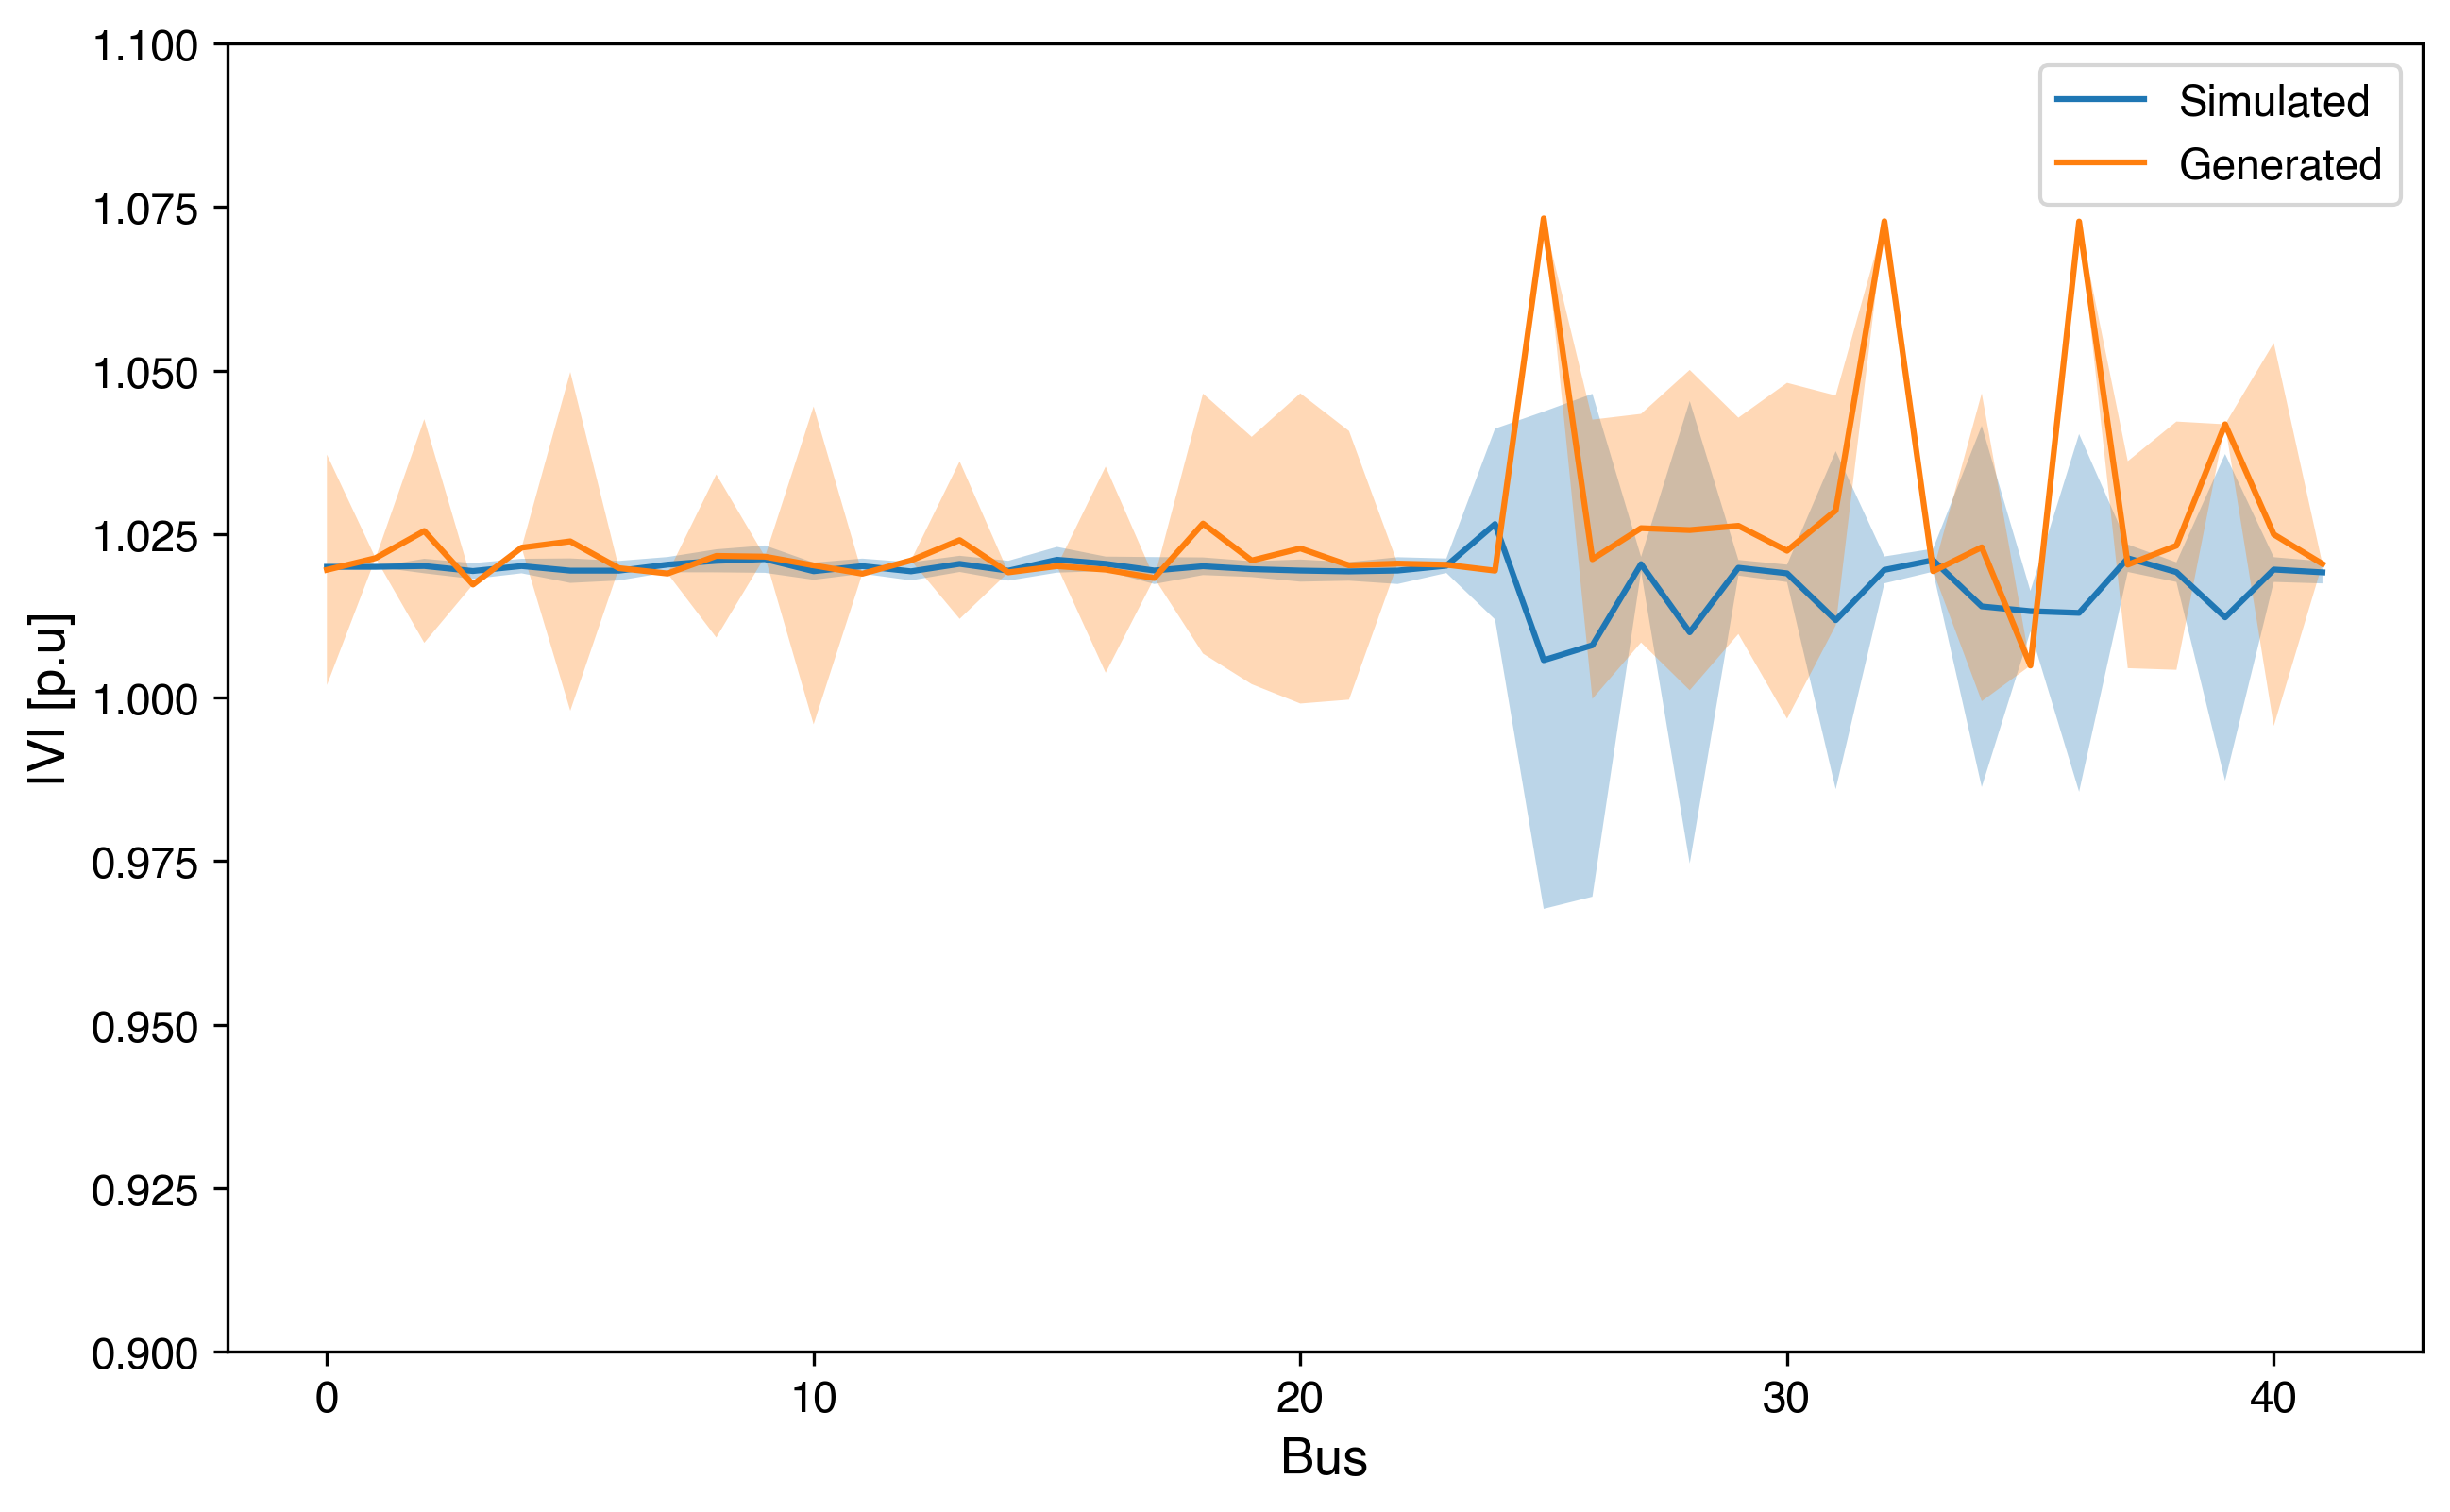

In [17]:
# Create the plot
plt.figure(figsize=(10, 6))
x = range(len(simulated_mean))
sns.lineplot(x=x, y=simulated_mean, label='Simulated')
plt.fill_between(x, simulated_mean - simulated_std, simulated_mean + simulated_std, alpha=0.3)
sns.lineplot(x=x, y=generated_mean, label='Generated')
plt.fill_between(x, generated_mean - generated_std, generated_mean + generated_std, alpha=0.3)          
plt.ylim(0.9,1.1)       
plt.xlabel('Bus')
plt.ylabel('|V| [p.u]')
plt.legend()
plt.show()

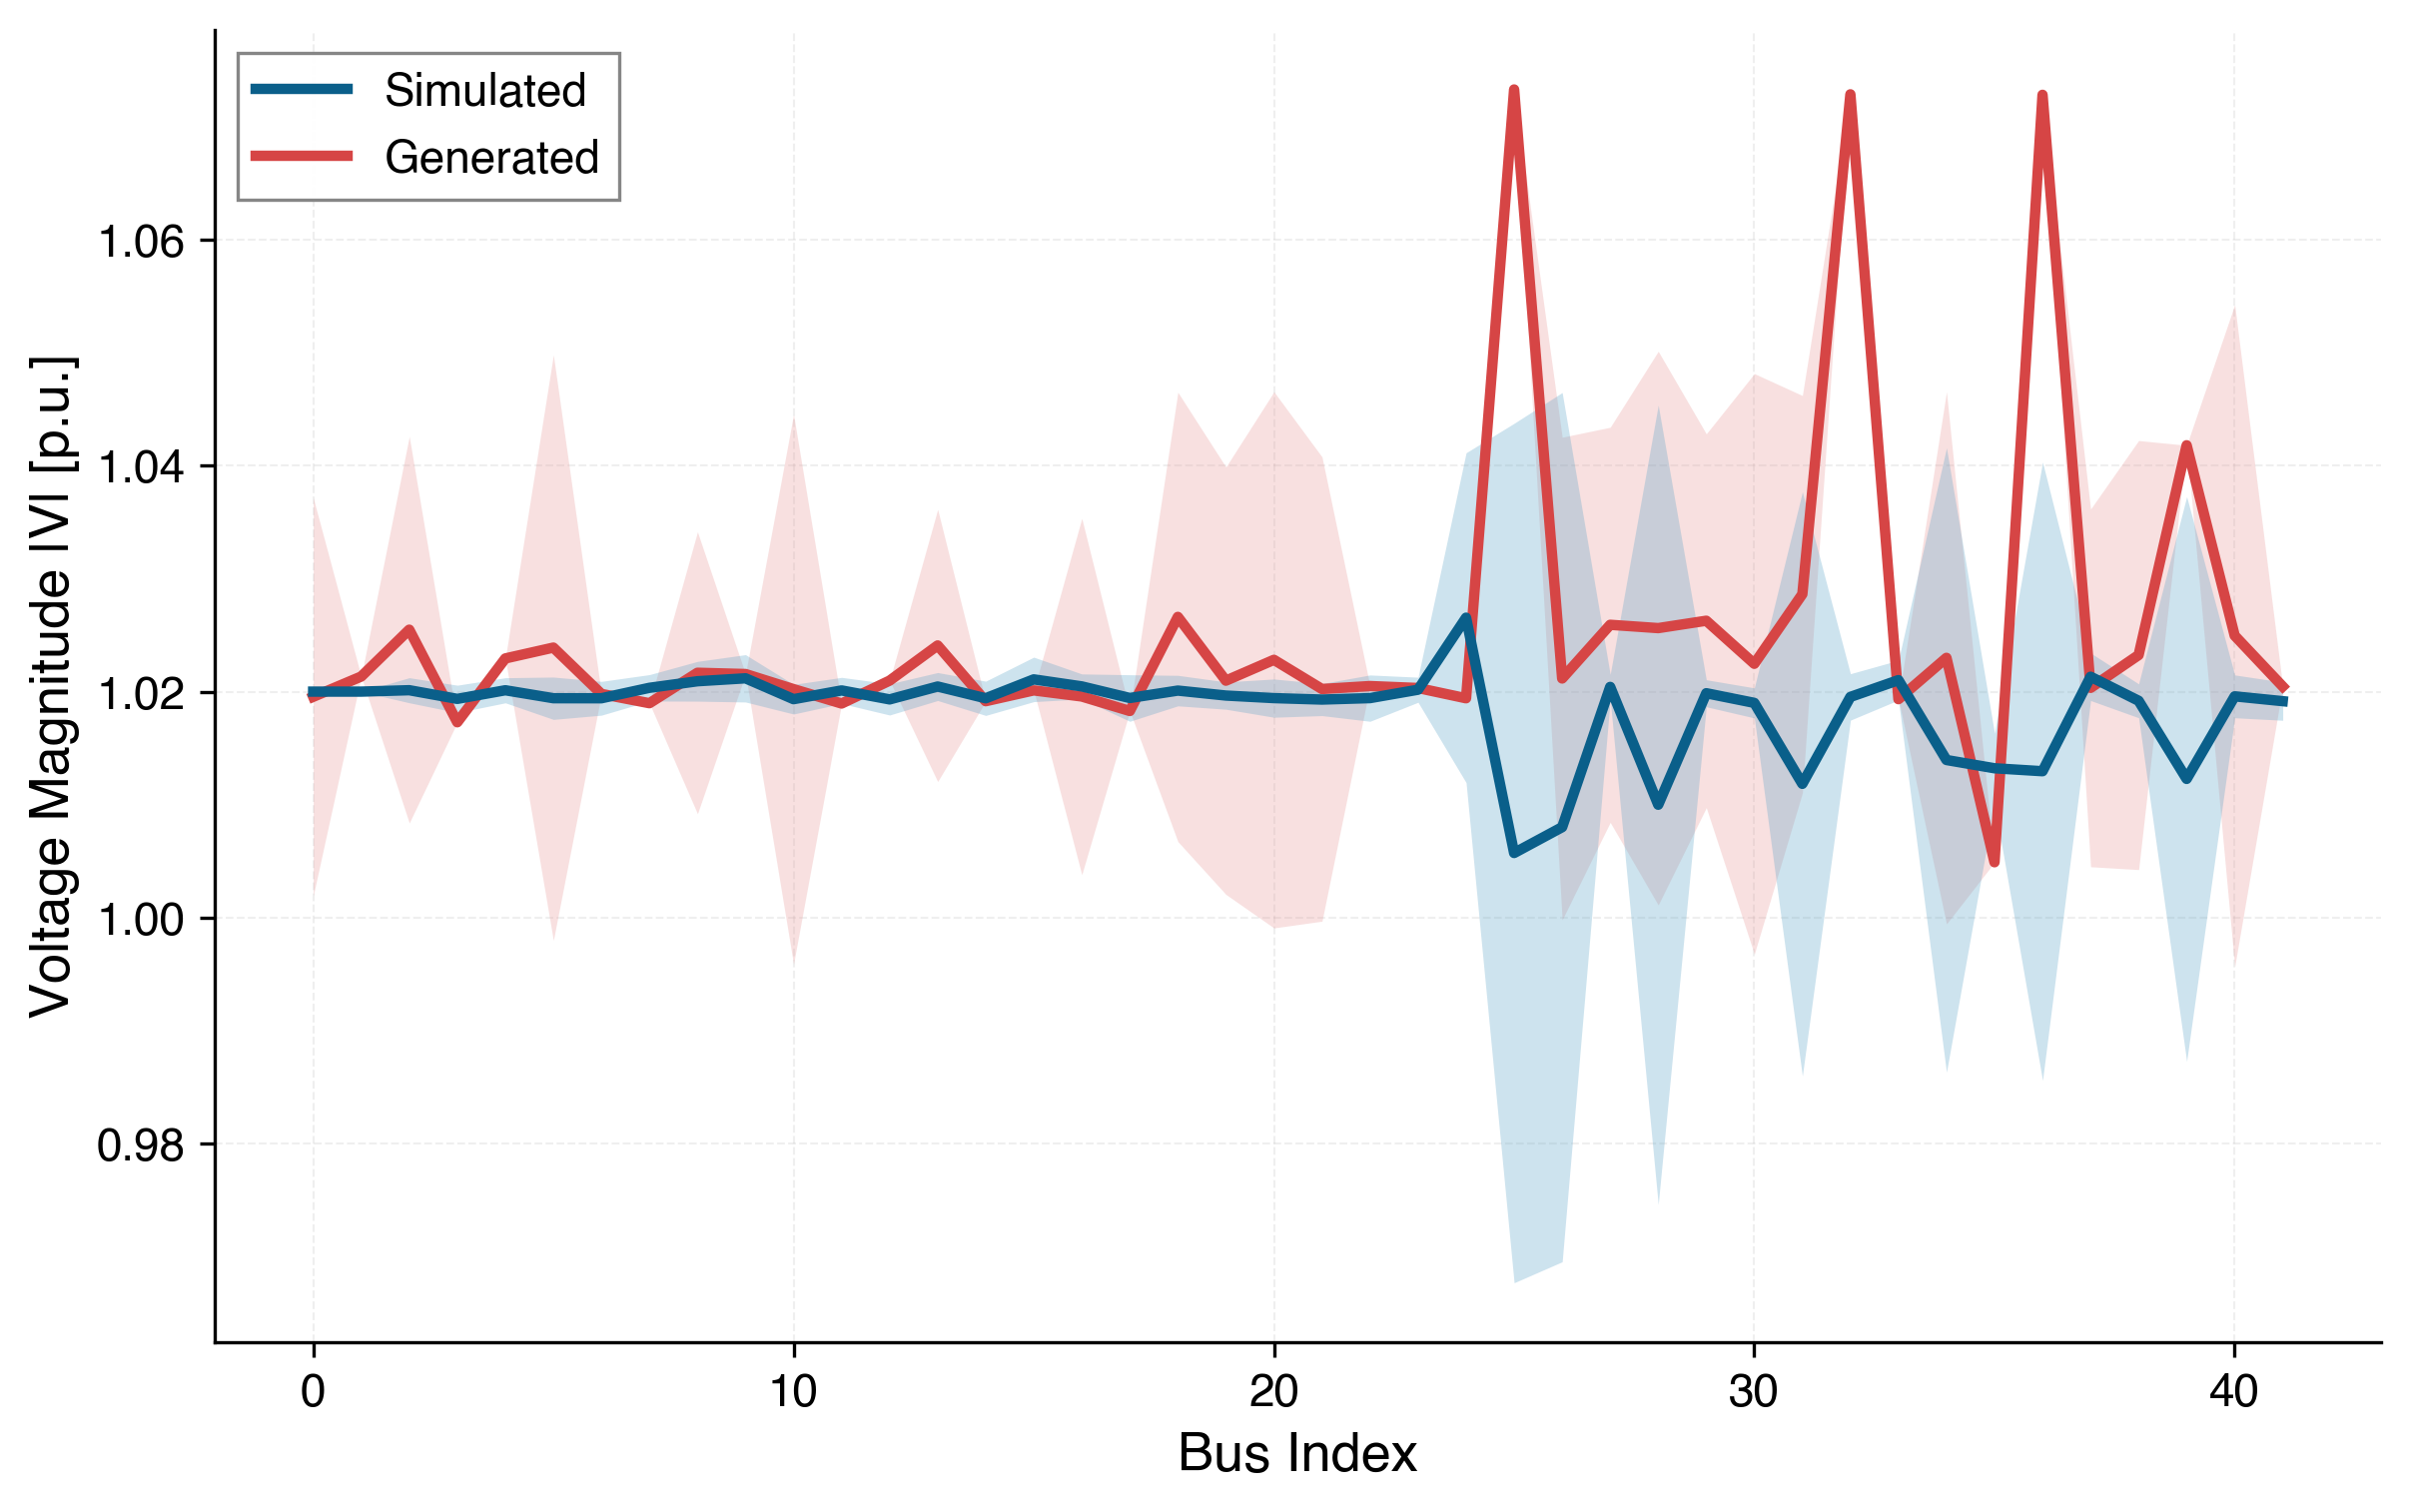

In [18]:
# Set publication-quality style with modern fonts
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'semibold'

# Create figure with better proportions
fig, ax = plt.subplots(figsize=(8, 5))

# Professional color palette
color_simulated = '#0A5F8A'  # Deep blue
color_generated = '#D64545'  # Warm red
fill_sim = '#5BA3C7'  # Light blue
fill_gen = '#E89B9B'  # Light red

x = range(len(simulated_mean))

# Plot simulated data
ax.plot(x, simulated_mean, 
        color=color_simulated, 
        linewidth=2.5, 
        label='Simulated',
        zorder=4)
ax.fill_between(x, 
                simulated_mean - simulated_std, 
                simulated_mean + simulated_std, 
                color=fill_sim,
                alpha=0.3,
                linewidth=0,
                zorder=2)

# Plot generated data
ax.plot(x, generated_mean, 
        color=color_generated, 
        linewidth=2.5, 
        label='Generated',
        zorder=3)
ax.fill_between(x, 
                generated_mean - generated_std, 
                generated_mean + generated_std, 
                color=fill_gen,
                alpha=0.3,
                linewidth=0,
                zorder=1)

# Labels with proper formatting
ax.set_xlabel('Bus Index', fontweight='normal')
ax.set_ylabel('Voltage Magnitude |V| [p.u.]', fontweight='normal')
# ax.set_title('Comparison of Simulated and Generated Voltage Profiles', 
        #      fontweight='semibold', pad=15)

# Add subtle grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

# # Optional: Add reference line at 1.0 p.u. (nominal voltage)
# ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=1.2, 
#            alpha=0.6, zorder=1, label='Nominal (1.0 p.u.)')

# Legend with refined styling
legend = ax.legend(frameon=True, 
                   loc='best',
                   framealpha=0.95,
                   edgecolor='gray',
                   fancybox=False,
                   shadow=False)
legend.get_frame().set_linewidth(0.8)

# Tight layout
plt.tight_layout(pad=0.5)

# Save options
plt.savefig('FIG_voltage_comparison.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('voltage_comparison.png', dpi=300, bbox_inches='tight')

plt.show()

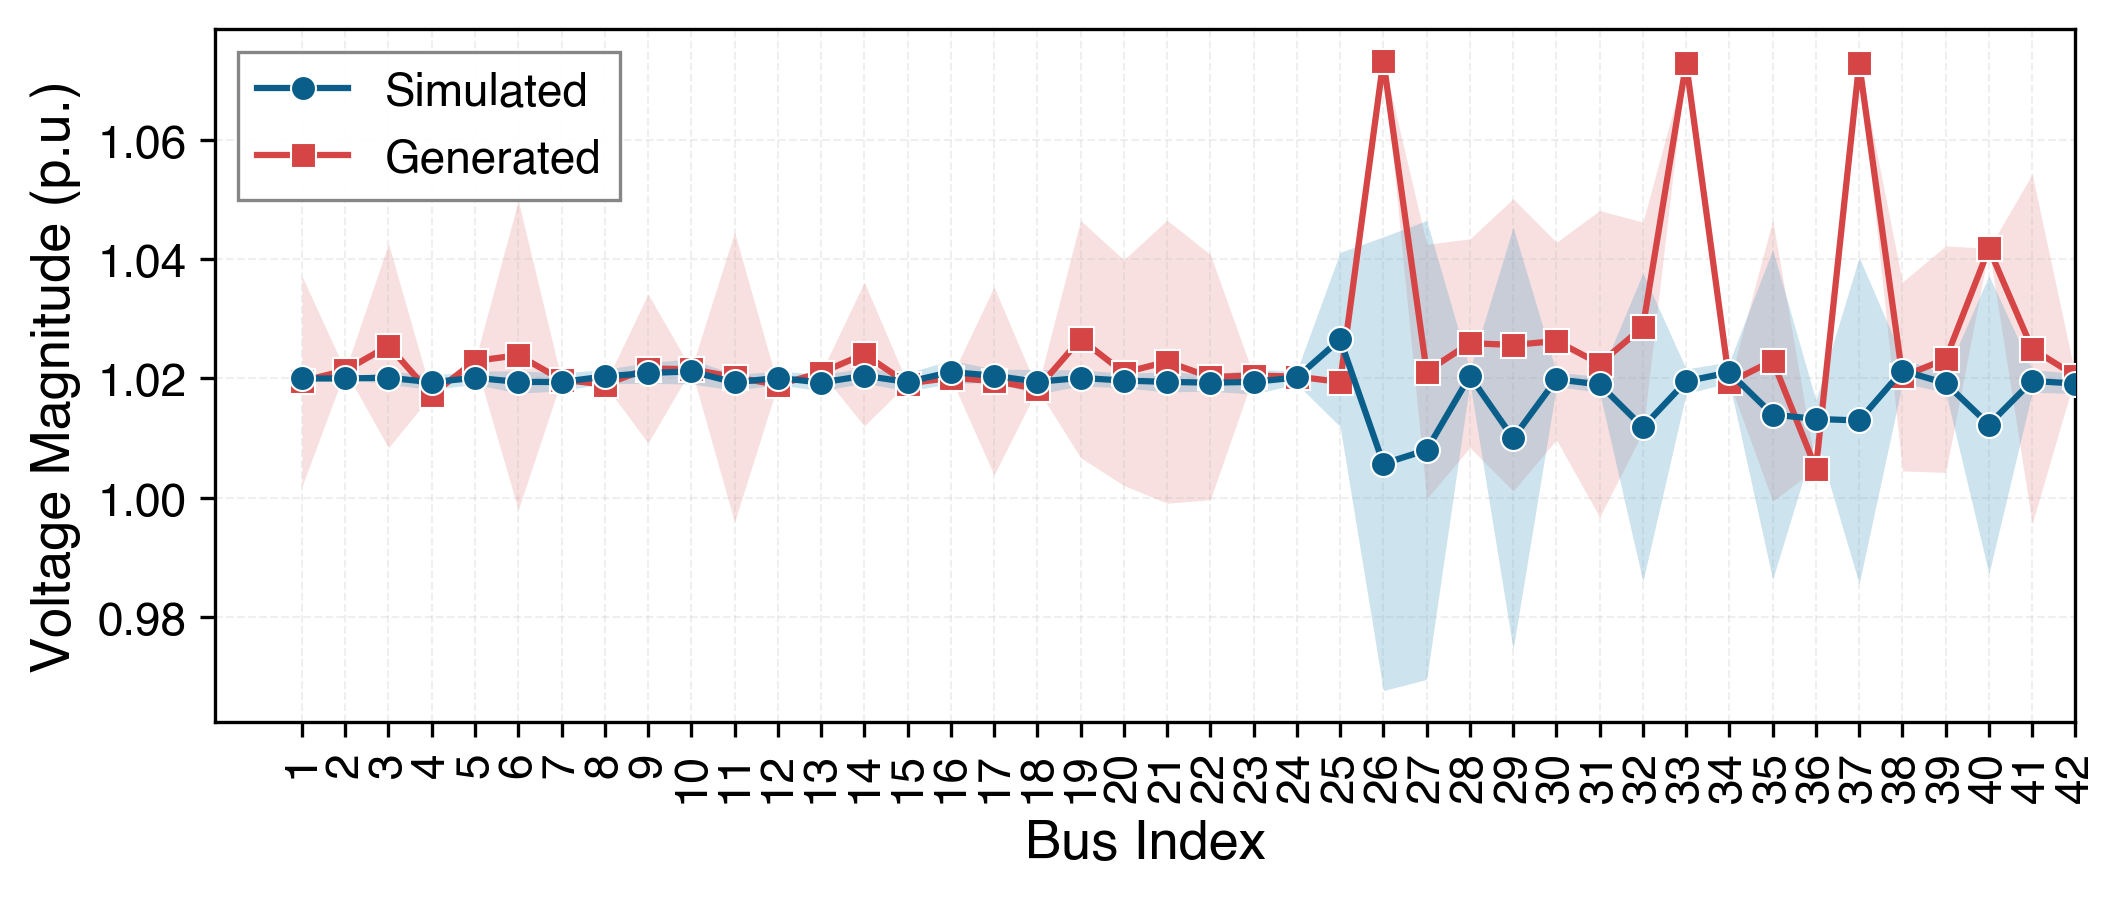

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set publication-quality style with modern fonts
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Proxima Nova', 'Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'semibold'

# Create figure with better proportions
fig, ax = plt.subplots(figsize=(8, 3))

# Professional color palette
color_simulated = '#0A5F8A'  # Deep blue
color_generated = '#D64545'  # Warm red
fill_sim = '#5BA3C7'  # Light blue
fill_gen = '#E89B9B'  # Light red

x = np.arange(len(simulated_mean)) + 1

# Plot simulated data (markers only)
ax.plot(x, simulated_mean, 
        color=color_simulated, 
        marker='o',
        markersize=6,
        linestyle='-',
        markeredgewidth=0.5,
        markeredgecolor='white',
        label='Simulated',
        zorder=4)
ax.fill_between(x, 
                simulated_mean - simulated_std, 
                simulated_mean + simulated_std, 
                color=fill_sim,
                alpha=0.3,
                linewidth=0,
                zorder=2)

# Plot generated data (markers only)
ax.plot(x, generated_mean, 
        color=color_generated, 
        marker='s',
        markersize=6,
        linestyle='-',
        markeredgewidth=0.5,
        markeredgecolor='white',
        label='Generated',
        zorder=3)
ax.fill_between(x, 
                generated_mean - generated_std, 
                generated_mean + generated_std, 
                color=fill_gen,
                alpha=0.3,
                linewidth=0,
                zorder=1)

# Labels with proper formatting
ax.set_xlabel('Bus Index', fontweight='normal')
ax.set_ylabel('Voltage Magnitude (p.u.)', fontweight='normal')
# ax.set_title('Comparison of Simulated and Generated Voltage Profiles', 
#              fontweight='semibold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(x, rotation=90)

# Add subtle grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(-1,42)

# Clean up spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_linewidth(0.8)
# ax.spines['bottom'].set_linewidth(0.8)

# Optional: Add reference line at 1.0 p.u. (nominal voltage)
# ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=1.2, 
#            alpha=0.6, zorder=1, label='Nominal (1.0 p.u.)')

# Legend with refined styling
legend = ax.legend(frameon=True, 
                   loc='best',
                   framealpha=0.95,
                   edgecolor='gray',
                   fancybox=False,
                   shadow=False)
legend.get_frame().set_linewidth(0.8)

# Tight layout
# plt.tight_layout(pad=0.5)

# Save options
plt.savefig('FIG_voltage_comparison.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('voltage_comparison.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('voltage_comparison.png', dpi=300, bbox_inches='tight')

plt.show()

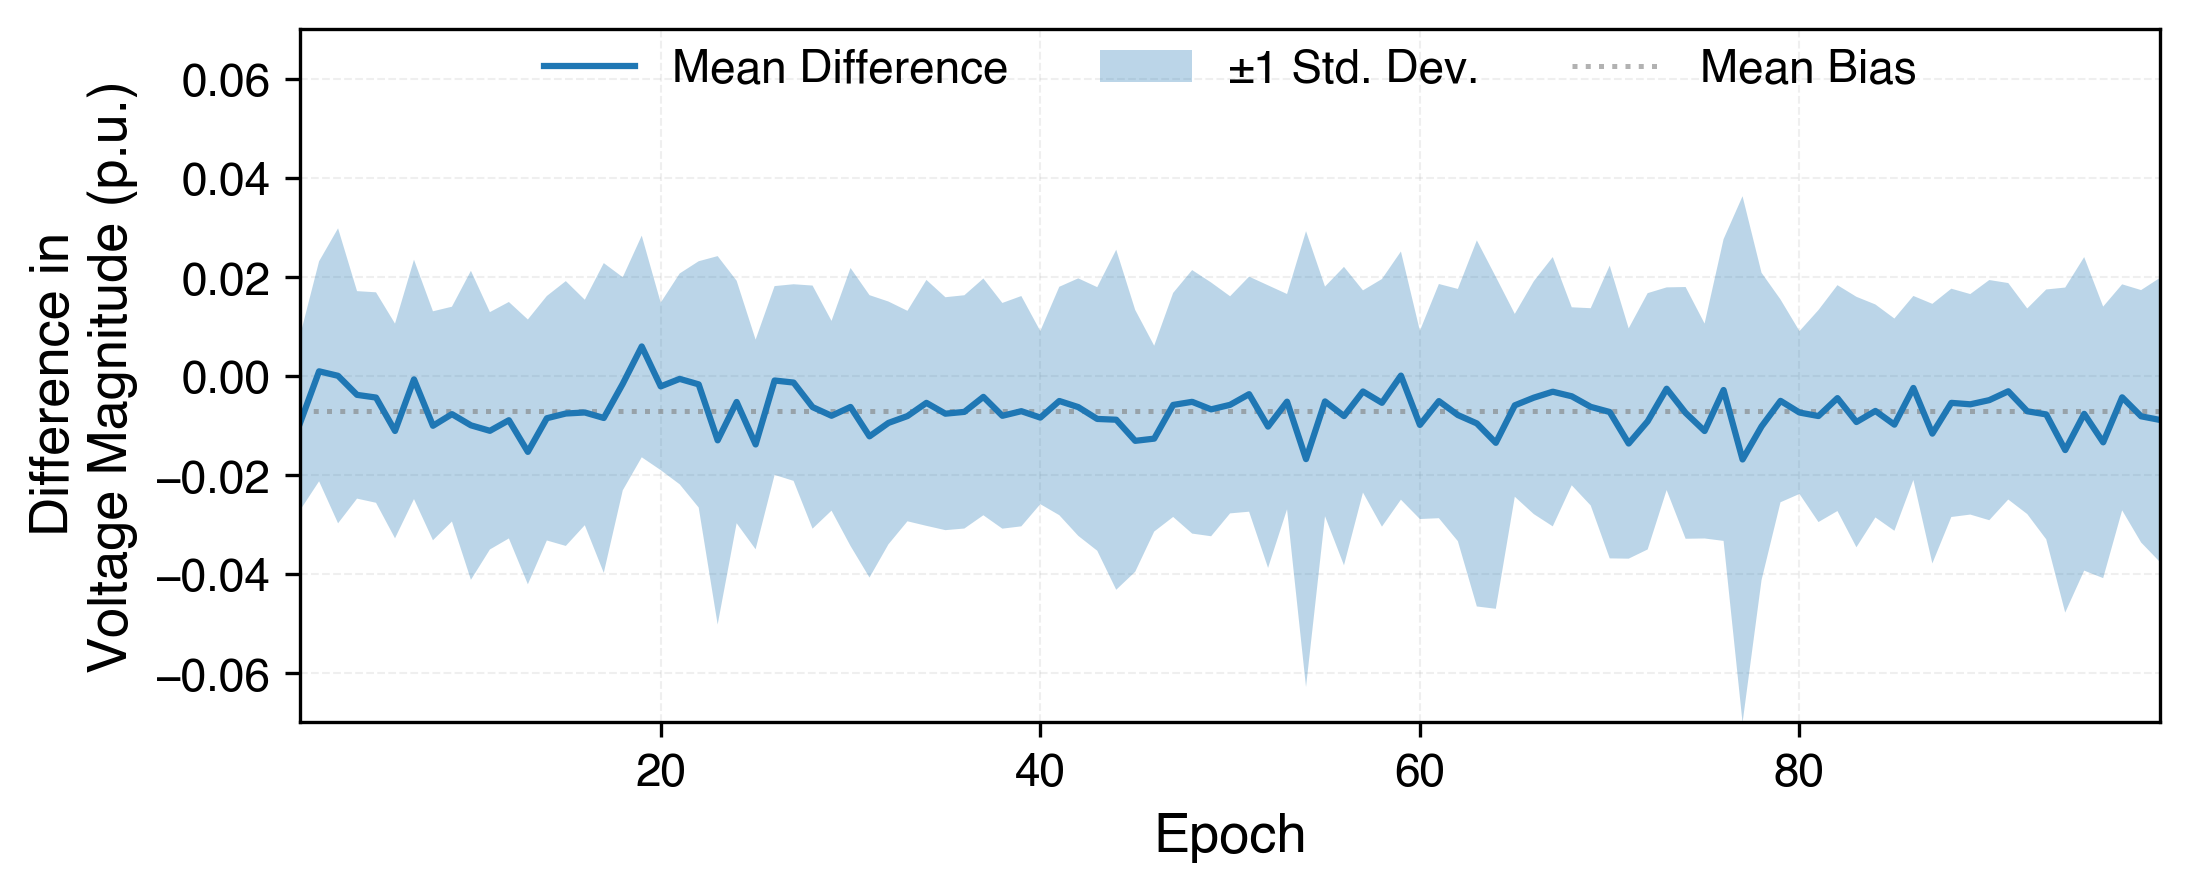

In [74]:
diff_sim_gen_df = simulated_v_pf_data_df - generated_v_df
diff_sim_gen_mean = diff_sim_gen_df.mean(axis=0)
diff_sim_gen_std = diff_sim_gen_df.std(axis=0)
diff_sim_gen_mean = np.asarray(diff_sim_gen_mean, dtype=float)
diff_sim_gen_std = np.asarray(diff_sim_gen_std, dtype=float)

mean_diff_mean = diff_sim_gen_mean.mean()

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'  # Modern math font
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'semibold'



# Create the plot 
fig, ax = plt.subplots(figsize=(8, 3))
x = np.arange(len(diff_sim_gen_mean)) + 1
sns.lineplot(x=x, y=diff_sim_gen_mean, label='Mean Difference')
plt.fill_between(x, diff_sim_gen_mean - diff_sim_gen_std, diff_sim_gen_mean + diff_sim_gen_std, alpha=0.3, label='±1 Std. Dev.')
plt.xlabel('Epoch')
plt.ylabel('Difference in \nVoltage Magnitude (p.u.)')

# Add grid for readability (subtle)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=1)

ax.axhline(y=mean_diff_mean, color='gray', linestyle=':', linewidth=1.2, 
           alpha=0.6, zorder=1, label='Mean Bias')

# Add the bias value as a tick on the y-axis
# yticks = list(ax.get_yticks())
# yticks.append(mean_diff_mean)  # add bias value
# ax.set_yticks(yticks)

# # Format so it shows the number (e.g., 0.1234)
# ax.set_yticklabels([f"{yt:.4f}" for yt in yticks])
ax.set_ylim(-0.07,0.07)
ax.set_axisbelow(True)
ax.set_xlim(1,99)

plt.legend(
    loc='lower center',     # place legend above the plot
    bbox_to_anchor=(0.5, 0.85),  # center it horizontally, push slightly above
    ncol=3,                 # number of columns (adjust depending on how many labels you have)
    frameon=False           # optional: remove legend box frame
)


plt.savefig('FIG_simulated_v_generated_mean.pdf', dpi=300, bbox_inches='tight')

plt.show()